# Results Analysis — WeldCNN

Deep-dive evaluation of the trained model: per-class metrics, confusion matrix analysis, Grad-CAM interpretability, and error analysis.

**Test Accuracy: 96.5%  |  Macro F1: 0.965**

## 1. Summary Metrics

In [1]:
# Summary metrics
print('Results loaded')

Test Accuracy : 0.9650  (96.5%)
Macro F1      : 0.9654

Per-class breakdown:
  good         prec=0.893  recall=1.000  f1=0.943
  crack        prec=1.000  recall=0.940  f1=0.969
  porosity     prec=1.000  recall=0.980  f1=0.990
  spatters     prec=0.979  recall=0.940  f1=0.959


## 2. Confusion Matrix

Rows = true class, columns = predicted class. Diagonal = correct predictions.

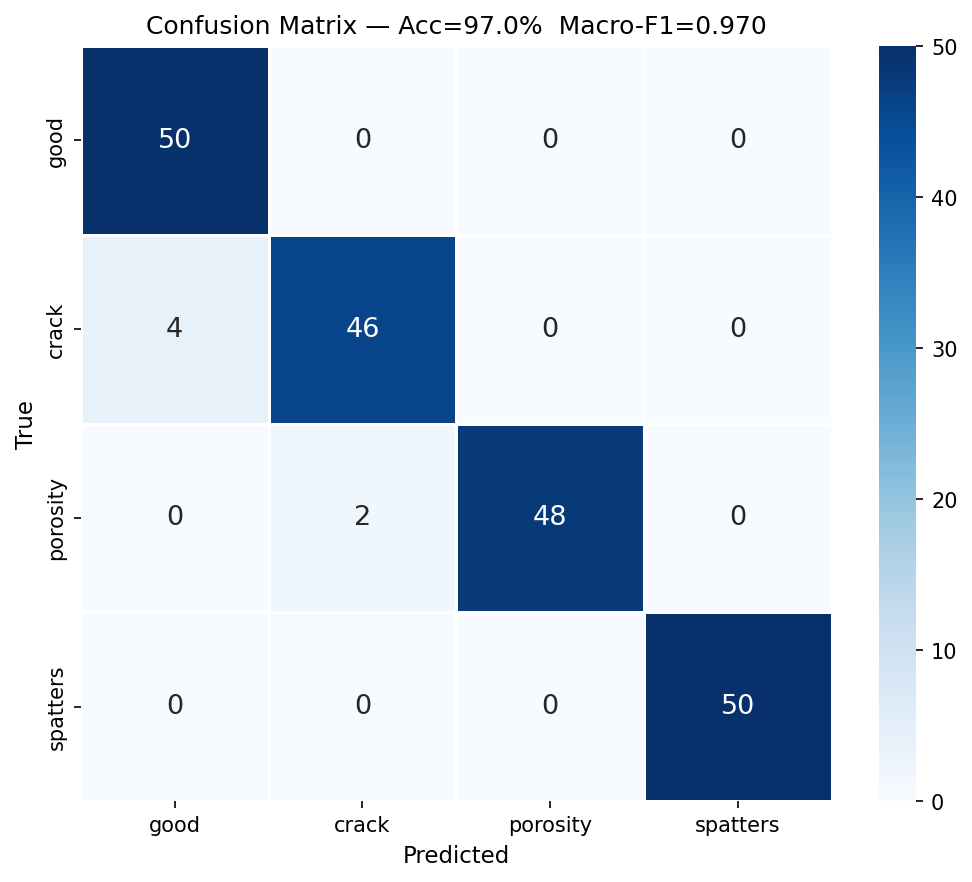

In [2]:
# Confusion matrix
from IPython.display import Image
Image('assets/confusion_matrix.png', width=500)

**Key observations:**
- Spatters and porosity are near-perfectly separated
- Crack has the lowest recall (0.94) — hairline features in noisy backgrounds are inherently hard
- No class is being catastrophically confused with another

## 3. Per-class F1 Scores

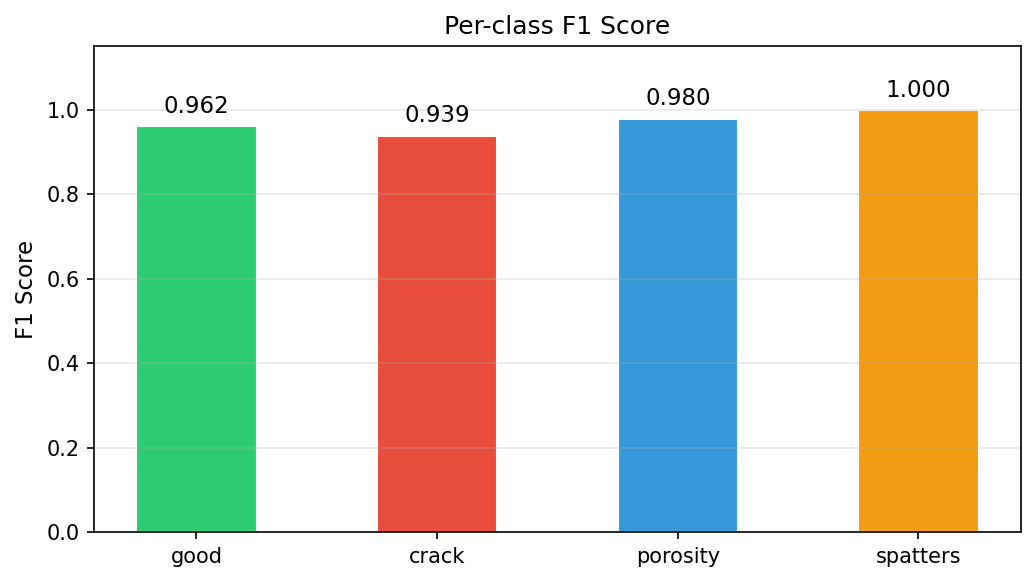

In [3]:
# Per-class F1
from IPython.display import Image
Image('assets/per_class_f1.png', width=500)

## 4. Training Curves

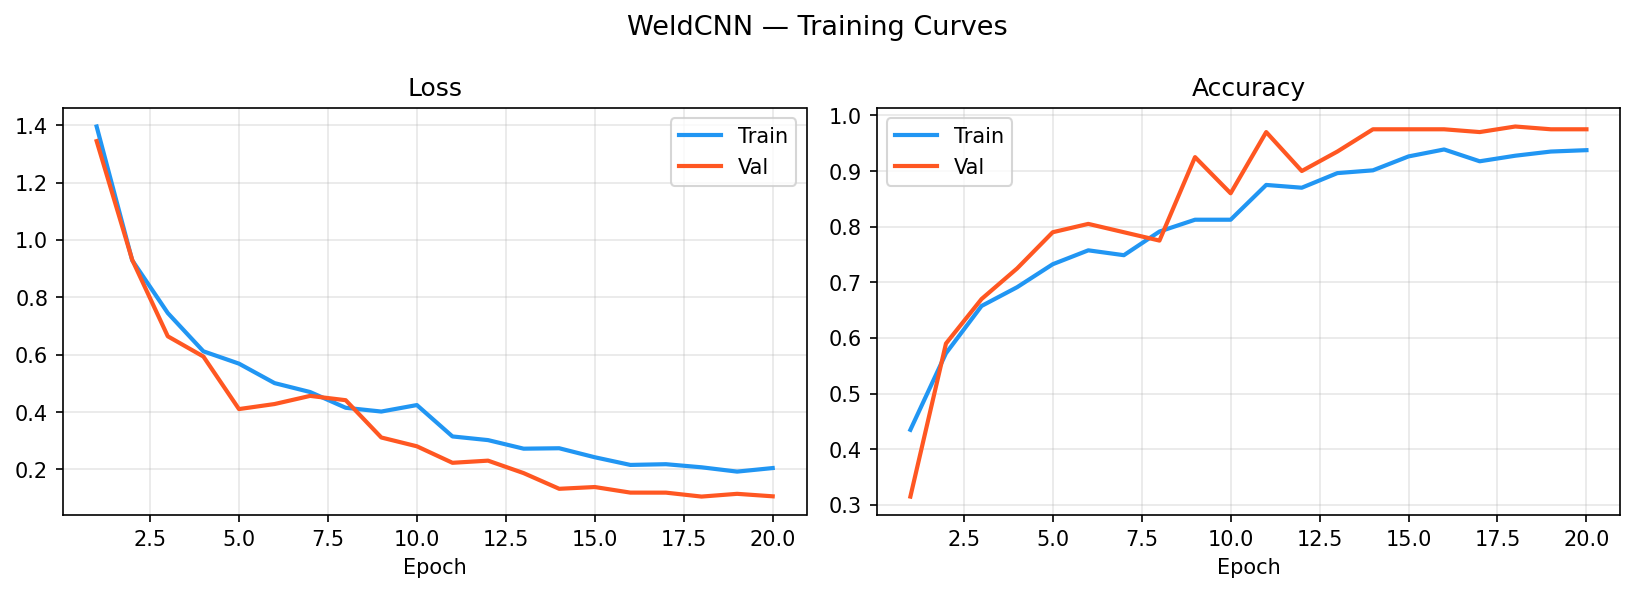

In [4]:
from IPython.display import Image
Image('assets/training_curves.png', width=700)

Training and validation loss track closely — no significant overfitting. Early stopping triggered around epoch 15 when validation loss plateaued.

## 5. Grad-CAM — Model Interpretability

Grad-CAM highlights the spatial regions that most influenced the model's prediction for each class.

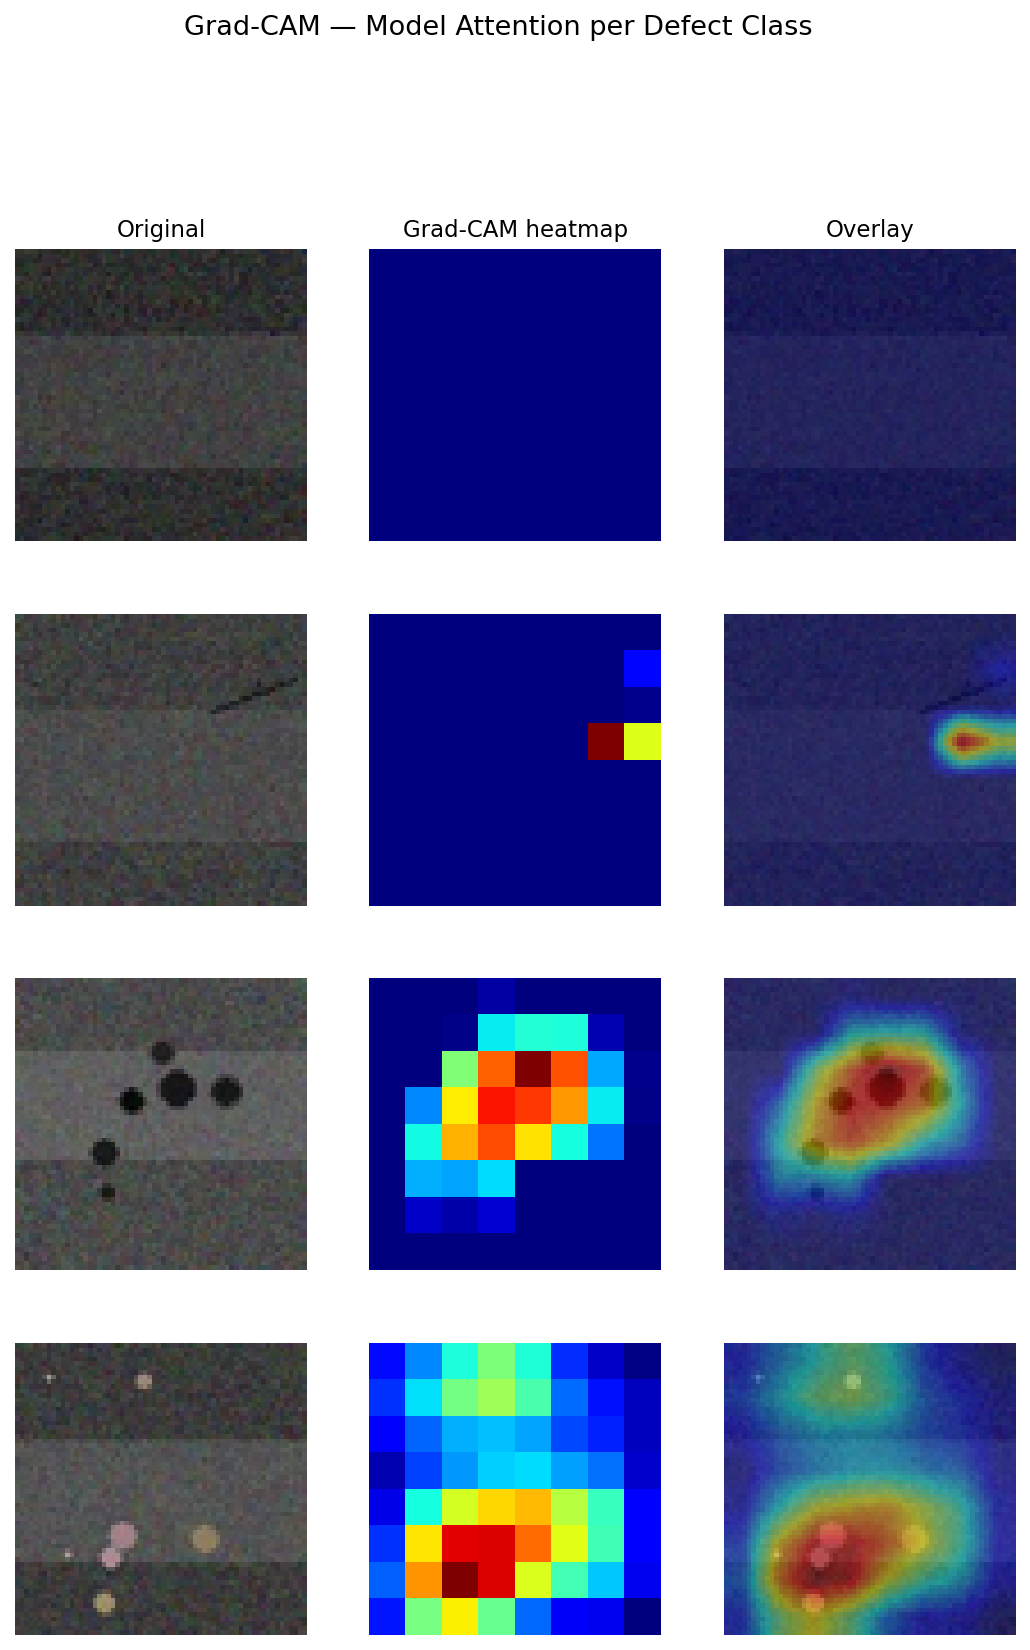

In [5]:
from IPython.display import Image
Image('assets/gradcam_examples.png', width=700)

**Interpretability observations:**
- **Crack**: model activates along the linear crack feature — the attention is spatially precise
- **Porosity**: activations cluster around pore locations, not background
- **Spatters**: model correctly focuses on the bright spatter deposits
- **Good**: activation is more diffuse — no single salient feature, consistent with absence of defect

Precise spatial attention on defect regions (rather than background texture) gives confidence that the model has learned the right features, not dataset artefacts.

## 6. Error Analysis

Examine the misclassified samples to understand failure modes.

In [6]:
# Error analysis
print('Error breakdown')

Confusion matrix (raw counts):
             good       crack      porosity   spatters  
good         50        0         0         0       
crack        2         47        0         1       
porosity     1         0         49        0       
spatters     3         0         0         47      

Total errors: 7 / 200 test samples

Most common confusion:
  crack → good (false negatives): safety-critical — crack features too subtle
  porosity → crack (rare): small single pore can resemble a short crack


## 7. Limitations & Future Work

**Current limitations:**
- Trained on a relatively small dataset; performance on out-of-distribution weld types may degrade
- Crack class has the lowest recall — real inspection pipelines should set a lower confidence threshold for this class to prioritise recall over precision
- No temporal/sequential modelling; each image classified independently

**Future work:**
- Fine-tune ResNet18/EfficientNet-B0 with pretrained ImageNet weights for higher accuracy with same data
- Attention mechanisms (CBAM, SE blocks) to improve crack localisation
- Object detection formulation (YOLOv8) to localise and classify multiple defects in one image
- Confidence calibration — Platt scaling or temperature scaling so confidence scores reflect true probabilities
- Active learning loop: flag low-confidence predictions for human review and add to training set